In [1]:
import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt
from detection import bandpass_filter
from refine import iterative_refine

npx_recording = np.memmap("../data/raw/c37_npx_raw.bin", mode='r', dtype=np.int16, order='C')
npx_recording = npx_recording.reshape((384, 4050171), order='F')

channels_subset = list(range(180, 220))
subset_data = npx_recording[channels_subset, :].T.astype(np.float32)
fs = 30000
filtered = bandpass_filter(subset_data, fs)

waveforms = np.load("../data/raw/waveforms.npy")
cluster_labels = np.load("../data/raw/cluster_labels.npy")
ground_truth_spikes = np.load("../data/raw/c37_extracellular_spikes.npy")

cluster_8_indices = np.where(cluster_labels == 8)[0]
print(f"Starting with {len(cluster_8_indices)} spikes from cluster 8")

Starting with 372 spikes from cluster 8


In [2]:
history = iterative_refine(filtered, cluster_8_indices, waveforms, fs, n_candidates=400, max_iterations=10)

iteration 0: stability=0.000
  similarity to original template: 0.985
iteration 1: stability=0.795
  similarity to original template: 0.969
iteration 2: stability=0.868
  similarity to original template: 0.953
iteration 3: stability=0.855
  similarity to original template: 0.932
iteration 4: stability=0.828
  similarity to original template: 0.905
iteration 5: stability=0.790
  similarity to original template: 0.863
iteration 6: stability=0.780
  similarity to original template: 0.810
iteration 7: stability=0.807
  similarity to original template: 0.769
iteration 8: stability=0.873
  similarity to original template: 0.750
iteration 9: stability=0.907
converged at iteration 9


In [3]:
from templates import template_match

final_template = history[-1]["template"]

matched_times, scores = template_match(filtered, final_template, fs, threshold=0.6)

tolerance_samples = int(0.001 * fs)
matched_is_true = np.zeros(len(matched_times), dtype=bool)
true_found = np.zeros(len(ground_truth_spikes), dtype=bool)

for i, t in enumerate(matched_times):
    close = np.abs(ground_truth_spikes - t) <= tolerance_samples
    if np.any(close):
        matched_is_true[i] = True
        true_found[close] = True

precision = matched_is_true.sum() / len(matched_times) * 100
recall = true_found.sum() / len(ground_truth_spikes) * 100
print(f"Converged template — Precision: {precision:.1f}%, Recall: {recall:.1f}%, matches: {len(matched_times)}")

Converged template — Precision: 1.0%, Recall: 10.6%, matches: 6723


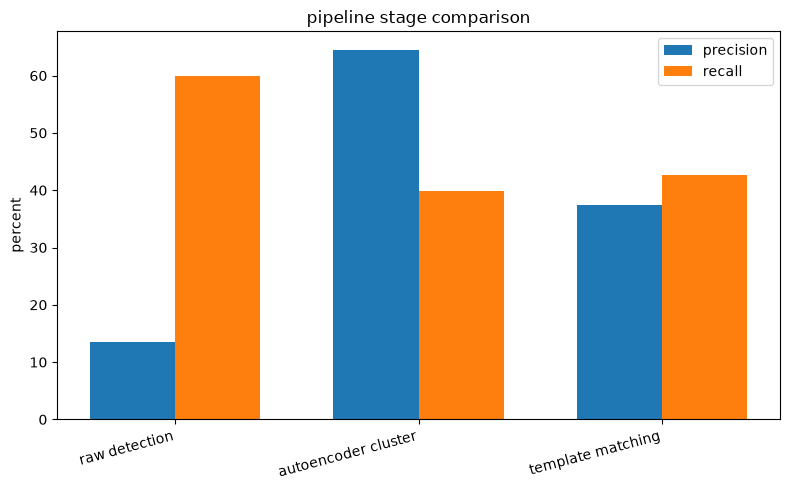

In [7]:
methods = ["raw detection", "autoencoder cluster", "template matching"]
precisions = [13.5, 64.5, 37.4]
recalls = [59.9, 39.9, 42.6]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(methods))
width = 0.35

ax.bar(x - width/2, precisions, width, label='precision')
ax.bar(x + width/2, recalls, width, label='recall')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15, ha='right')
ax.set_ylabel("percent")
ax.set_title("pipeline stage comparison")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/final_comparison.png")
plt.show()